<a href="https://colab.research.google.com/github/FraIL1/Practicum-of-programming/blob/main/HMW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from datetime import datetime
from torchvision.datasets import CIFAR100
from torchvision import transforms
now = datetime.now()
warnings.filterwarnings('ignore')
%matplotlib inline
# Форматируем дату и время
date_time = now.strftime("%Y-%m-%d %H:%M:%S")

In [17]:
Name="Пономарев Артём Алексеевич"
Group="ЗФИбд-01-24"
StudentNumber="1132243698"
print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")

Name: Пономарев Артём Алексеевич, Group: ЗФИбд-01-24, StudentNumber: 1132243698, DateTime: 2026-04-27 13:18:51


#### Домашнее задание № 1
- Реализовать класс для классификации
- Реализовать класс для регресии

In [18]:
class KnnClassifier:
    def __init__(self, k: int):
        self.k = k

    def fit(self, X, y):
        # Просто запоминаем обучающую выборку
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []

        for x in X:
            # Считаем расстояния до всех точек
            distances = np.sqrt(((self.X_train - x) ** 2).sum(axis=1))

            # Берём индексы k ближайших
            k_idx = np.argsort(distances)[:self.k]

            # Достаём их классы
            k_labels = self.y_train[k_idx]

            # Голосование (самый частый класс)
            values, counts = np.unique(k_labels, return_counts=True)
            predictions.append(values[np.argmax(counts)])

        return np.array(predictions)

In [19]:
model = KnnClassifier(k=3)
X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
X_test = np.array([[5, 5], [2, 2]])
model.fit(X_train, y_train)
assert all(model.predict(X_test) == [1, 0])

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")

Name: Пономарев Артём Алексеевич, Group: ЗФИбд-01-24, StudentNumber: 1132243698, DateTime: 2026-04-27 13:18:51


In [20]:
class KnnRegressor:
    def __init__(self, k: int):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []

        for x in X:
            distances = np.sqrt(((self.X_train - x) ** 2).sum(axis=1))
            k_idx = np.argsort(distances)[:self.k]
            k_values = self.y_train[k_idx]

            # Среднее значение — это регрессия
            predictions.append(np.mean(k_values))

        return np.array(predictions)

In [21]:
reg_model = KnnRegressor(k=3)
X_train_reg = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
y_train_reg = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
reg_model.fit(X_train_reg, y_train_reg)
X_test_reg = np.array([[5.1, 5.1], [2.1, 2.1]])
predictions = reg_model.predict(X_test_reg)
expected = np.array([5.0, 2.0])
assert np.allclose(predictions, expected)

print(f"Предсказания: {predictions}")

Предсказания: [5. 2.]


#### Домашнее задание № 2

В рамках данного задания необходимо реализовать  метода классификации изображений — k-nearest neighbors  на датасете CIFAR-100.

Цель: исследовать качество работы алгоритма.

### Требования к выполнению

1. Загрузить обучающую выборку.
2. Случайным образом выбрать:
    - 20 000 изображений для обучения модели
    - 4 000 изображений для тестирования
3. Реализация метода KNN  
    - Обучить классификатор KNN.
    - Провести эксперименты с различными значениями параметра k (например: 1, 3, 5, 7).
    - Оценить качество модели на тестовой выборке.



In [22]:
!pip install torch torchvision

In [23]:
def load_cifar100_numpy(root="./data", train=True):
    """
    Возвращает:
      X: np.ndarray shape (N, 32, 32, 3), dtype uint8
      y: np.ndarray shape (N,)
    """
    # Скачиваем и загружаем данные
    ds = CIFAR100(root=root, train=train, download=True)

    # ds.data имеет размерность (N, 32, 32, 3) и тип uint8
    X = ds.data
    # ds.targets список меток, преобразуем в numpy массив
    y = np.array(ds.targets, dtype=np.int64)
    classes = ds.classes

    return X, y, classes

# 1) Загружаем CIFAR-100 (train часть)
X, y, classes = load_cifar100_numpy()

def show_images(X, y, classes, n=10):
    plt.figure(figsize=(15,3))

    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(X[i])
        plt.title(classes[y[i]], fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def show_one_image_per_class(X, y, classes):
    num_classes = len(classes)
    shown = set()
    selected_images = []
    selected_labels = []

    # ищем по одному примеру каждого класса
    for img, label in zip(X, y):
        if label not in shown:
            shown.add(label)
            selected_images.append(img)
            selected_labels.append(label)
        if len(shown) == num_classes:
            break

    # рисуем сетку 10x10
    plt.figure(figsize=(20,20))


    for i in range(num_classes):
        plt.subplot(10, 10, i+1)
        plt.imshow(selected_images[i])
        plt.title(classes[selected_labels[i]], fontsize=6)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

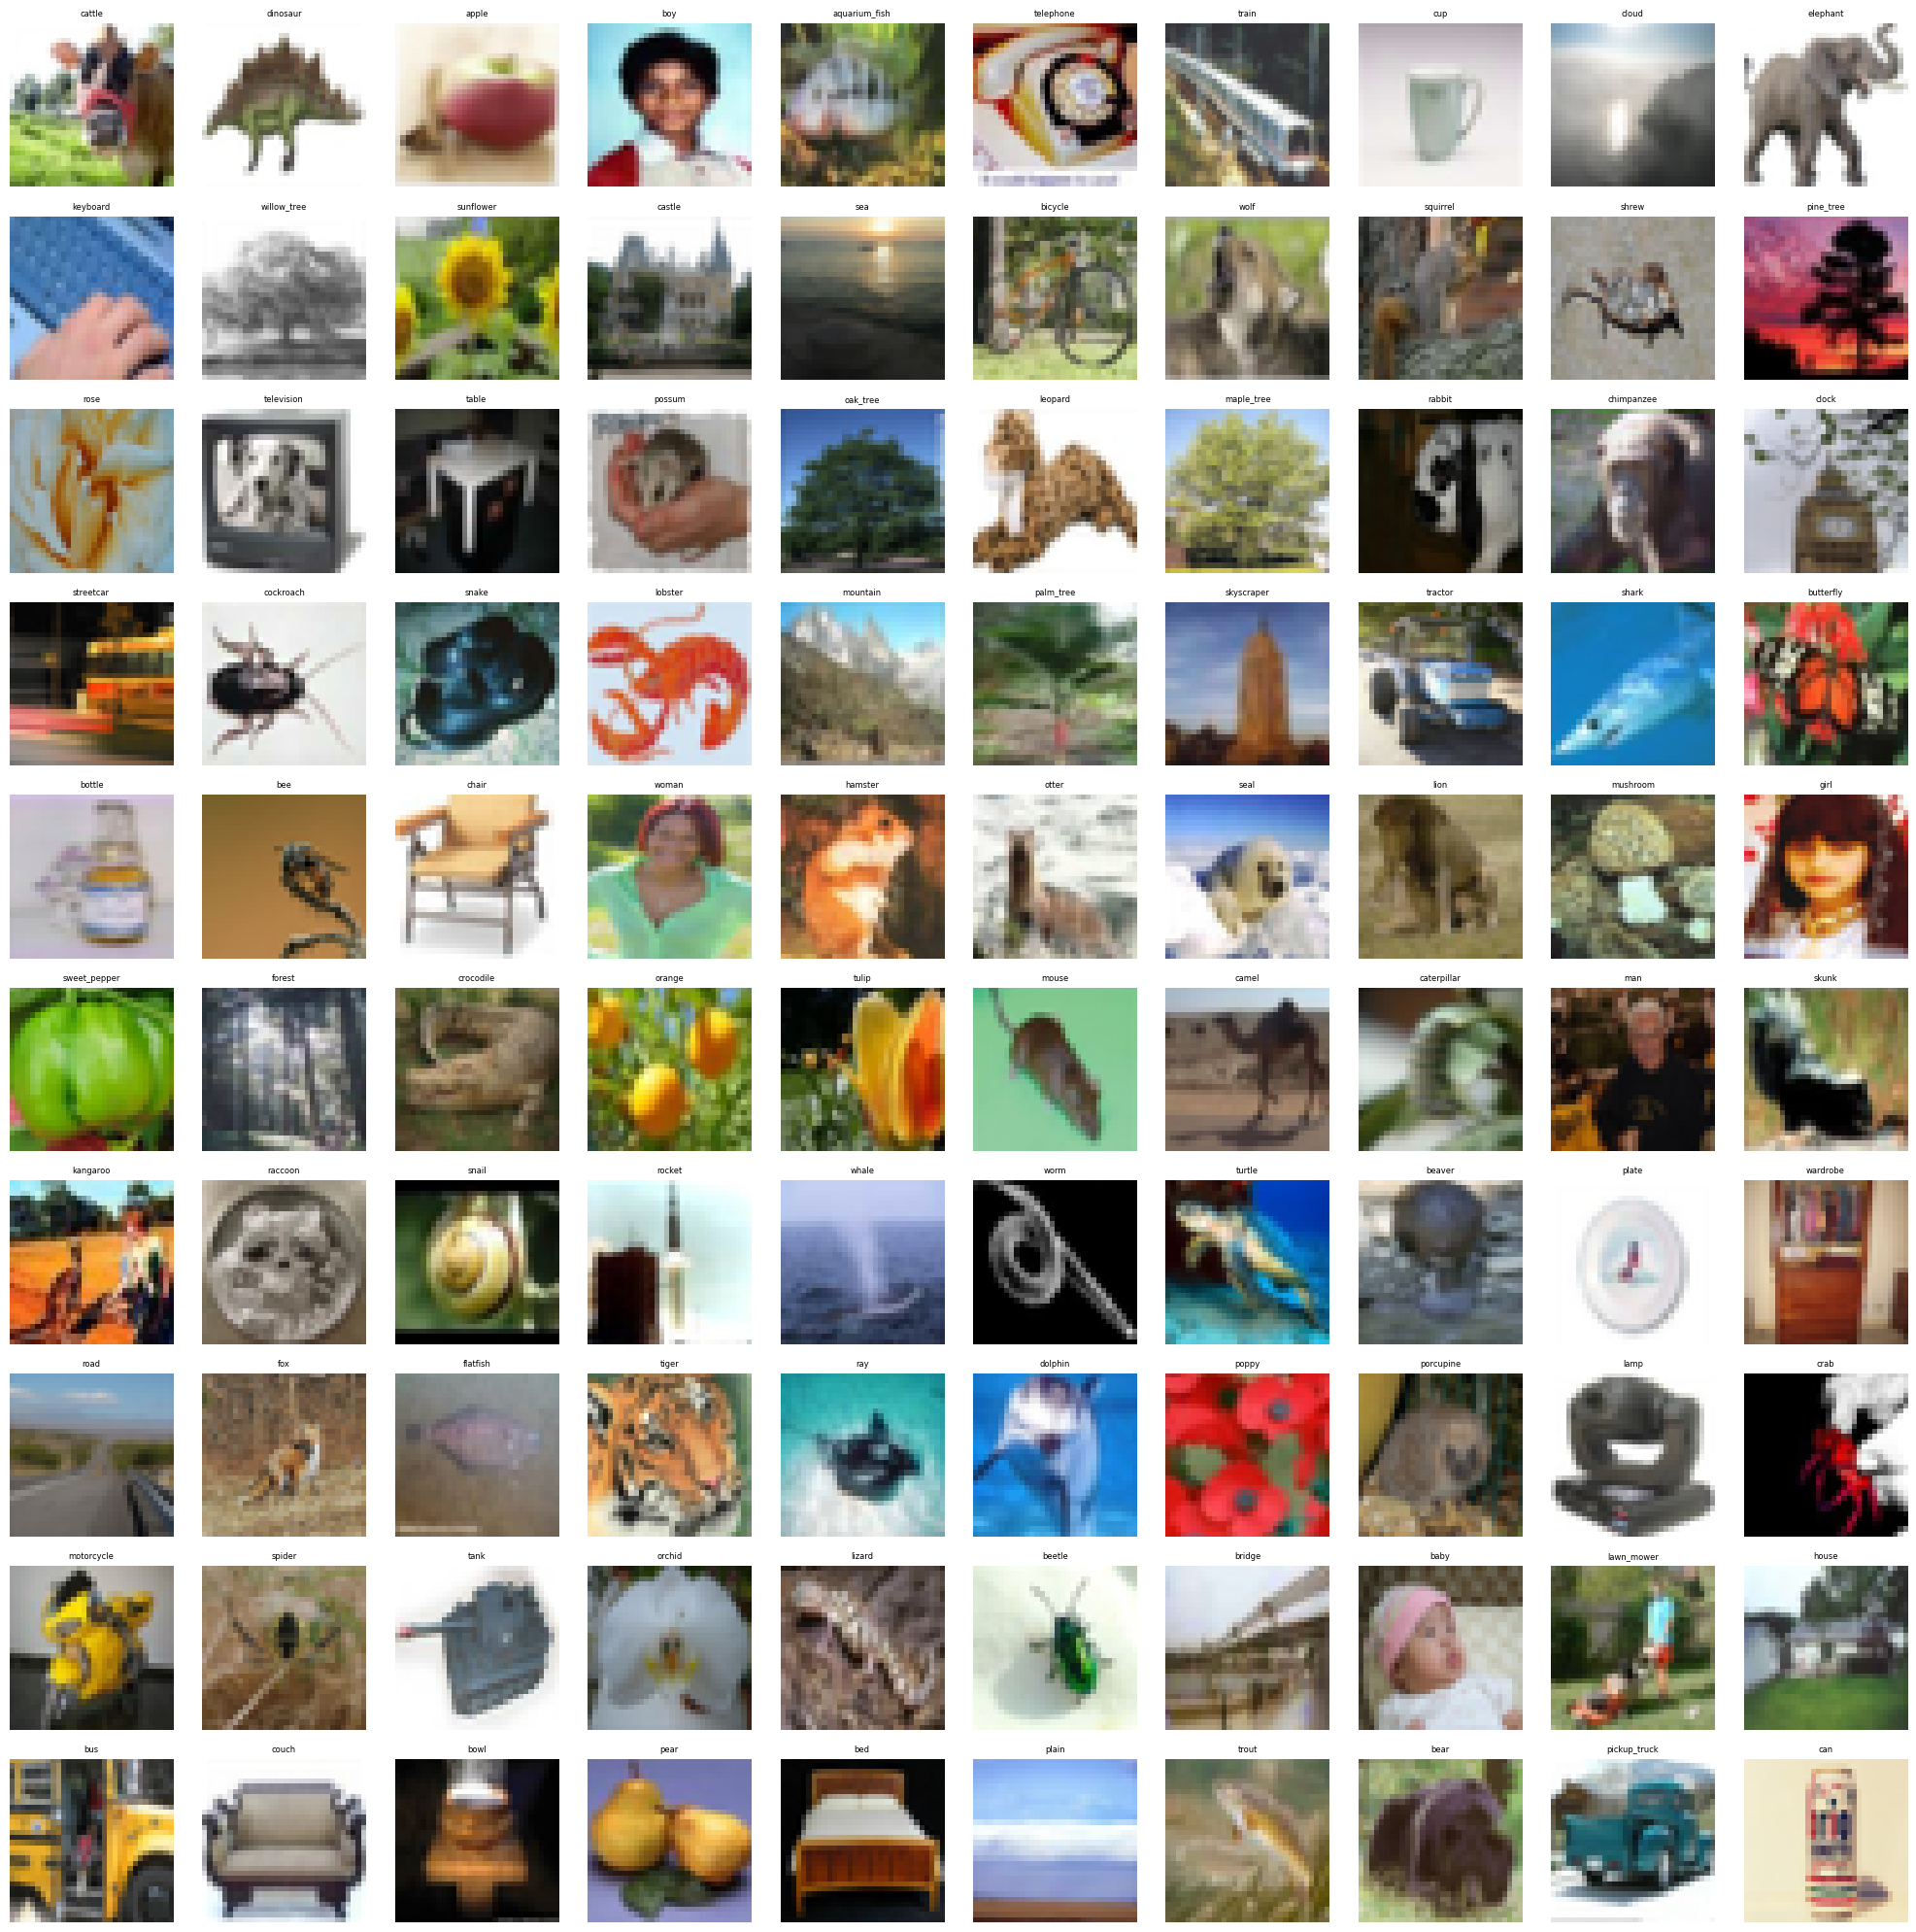

In [24]:
show_one_image_per_class(X, y, classes)

In [25]:
# уменьшаем размер данных
indices = np.random.permutation(len(X))
train_idx = indices[:20000]
test_idx = indices[20000:24000]

X_train = X[train_idx].reshape(20000, -1)  # flatten
y_train = y[train_idx]

X_test = X[test_idx].reshape(4000, -1)
y_test = y[test_idx]

k_values = [3, 7, 10, 15, 20]
results = {}

for k in k_values:
    model = KnnClassifier(k=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = np.mean(y_pred == y_test)

    results[k] = accuracy
    print(f"k = {k}, точность = {accuracy:.4f}")

k = 3, точность = 0.0698
k = 7, точность = 0.0747
k = 10, точность = 0.0757
k = 15, точность = 0.0737
k = 20, точность = 0.0722


#### Домашнее задание № 3

Задача предсказания цены бриллианта price

- Проверить наличие пропущенных значений, дубликатов, выбросов и шума в данных.
    - Провести полный разведочный анализ данных (EDA), включающий:
        - Анализ структуры и типов данных.
        - Подсчёт количества пропущенных значений и дубликатов.
        - Определение выбросов с помощью описательной статистики и визуальных методов
        - Проверку распределения признаков
        - Анализ категориальных признаков

- Определить, какие числовые признаки наиболее сильно коррелируют с целевой переменной.
    - Построить матрицу корреляций
    - Визуализировать её с помощью тепловой карты (heatmap)
- Разделить выборку на тренировочную и тестовую.
- Масштабировать данные.
- обучить модель с использованием KnnRegressor (задание № 1) и LinearRegression (sklearn)
- Визуализировать результат.
    - Построить графики предсказанных и истинных значений.
    - Построить диаграммы ошибок и метрики качества.
- Напишите выводы.



In [64]:
data = pd.read_csv('data1.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [65]:
print("Информация о данных:")
print(data.info())

print("\nПропущенные значения:")
print(data.isnull().sum())

print("\nКоличество дубликатов:", data.duplicated().sum())

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB
None

Пропущенные значения:
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Количество дубликатов: 0


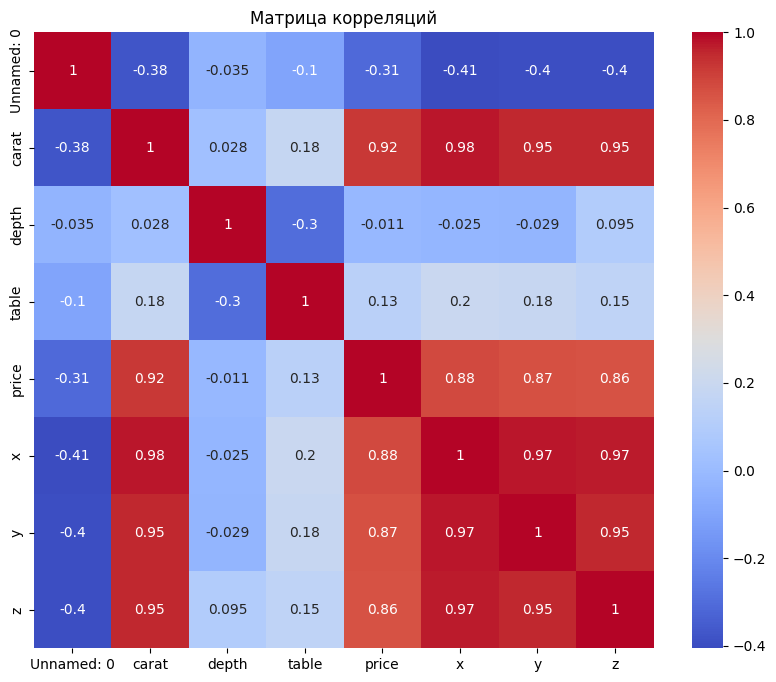

In [66]:
import seaborn as sns


corr = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Матрица корреляций")
plt.show()

Метрики KNN:
MSE: 588692.7251649981
R2: 0.9629678972636161

Метрики линейной регрессии:
MSE: 1282237.9409818377
R2: 0.9193399796988827


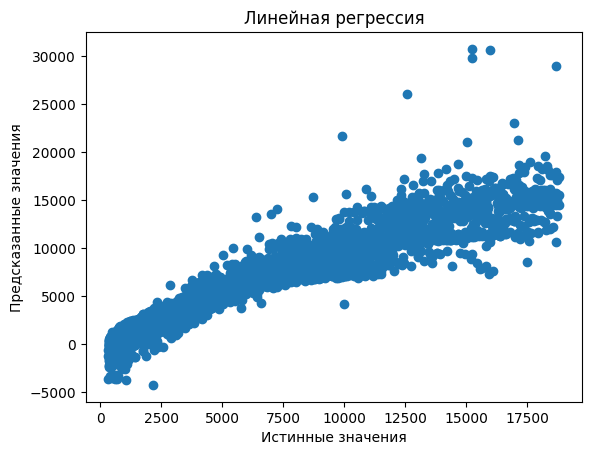

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


X = data.drop("price", axis=1)
y = data["price"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN
knn = KnnRegressor(k=5)
knn.fit(X_train, y_train.values)
y_pred_knn = knn.predict(X_test)

# Линейная регрессия
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Метрики KNN:")
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("R2:", r2_score(y_test, y_pred_knn))

print("\nМетрики линейной регрессии:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Линейная регрессия")
plt.show()

#### Домашнее задание № 4
Задача для прогнозирования стоимости квартиры. Датасет содержит следующую информацию: количество комнат, общая площадь, жилая площадь, этаж, площадь кухни, расстояние от аэропорта, расстояние до центра города
1. Обучите модель на основе этих данных. Используйте метод градиентный спуск.
2. Посчитайте среднюю квадратичную ошибку и визуализируйте
3. Напишите выводы и интерпретируйте, как вы подбирали гиперпараметры

In [84]:
data = np.loadtxt("data2.csv",delimiter=",", skiprows=1)

Финальная ошибка: 52834938705870.2


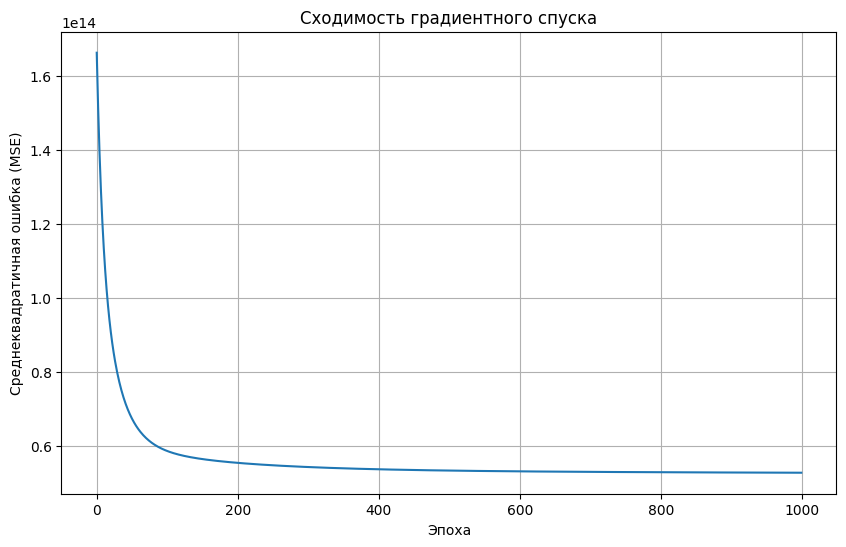

Name: Пономарев Артём Алексеевич, Group: ЗФИбд-01-24, StudentNumber: 1132243698, DateTime: 2026-04-27 13:18:51


In [85]:
X_raw = data[:, :-1].astype(np.float64)
y = data[:, -1].astype(np.float64)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Добавляем столбец единиц для bias
X = np.c_[np.ones(X_scaled.shape[0]), X_scaled]

# Инициализация весов
w = np.zeros(X.shape[1])

lr = 0.01
epochs = 1000

losses = []

for _ in range(epochs):
    y_pred = X @ w
    error = y_pred - y

    loss = np.mean(error ** 2)
    losses.append(loss)

    grad = 2 * X.T @ error / len(y)
    w -= lr * grad

print("Финальная ошибка:", losses[-1])

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title("Сходимость градиентного спуска")
plt.xlabel("Эпоха")
plt.ylabel("Среднеквадратичная ошибка (MSE)")
plt.grid(True)
plt.show()


print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")

#### Домашнее задание № 5
Следующий датасет содержит нелинейные данные. Нам необходимо найти оптимальную модель, чтобы прогнозировать с минимальными ошибками.
1. Используйте обычный градиентный спуск и визуализируйте результат.
2. Используйте полиномиальную регрессию и найдите необходимую степень полинома и визуализируйте результат.
3. Напишите выводы.

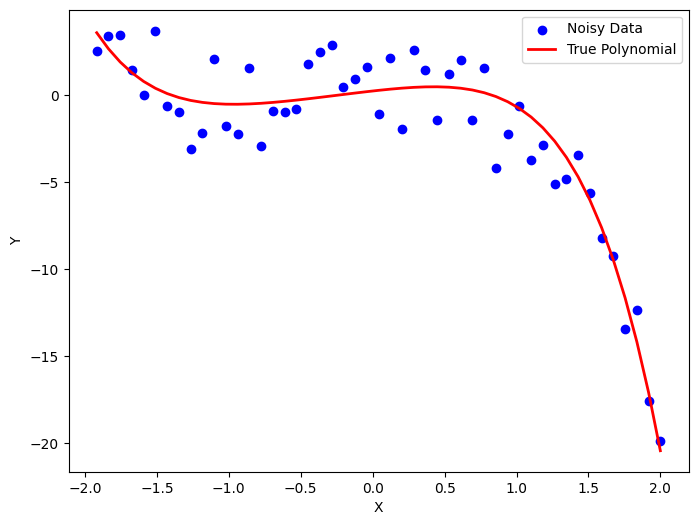

In [95]:
data = np.loadtxt("data6.csv",delimiter=",", skiprows=1).T.tolist()
x=np.array(data[0])
y_noisy=np.array(data[1])
y_true=np.array(data[2])

plt.figure(figsize=(8, 6))
plt.scatter(x, y_noisy, label='Noisy Data', color='blue')
plt.plot(x, y_true, label='True Polynomial', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [102]:
### YOUR CODE:

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")

Name: Пономарев Артём Алексеевич, Group: ЗФИбд-01-24, StudentNumber: 1132243698, DateTime: 2026-04-27 13:18:51


### Домашнее задание № 6
На основе сгенерированных данных выполните следующие пункты:
1. Обучите модель
2. Визуализируйте траекторию градиентного спуска
3. Проверьте влияние размера шага на сходимость модели
    $\alpha = 0.0001$ , $\alpha = 0.01$ , $\alpha = 0.1$

4. Масштабируйте данные и проверьте сходимость модели
```python
X_new = X.copy()
X_new[:,1] = X_new[:,1] * 5
```
4. Напишите выводы.

In [97]:
n_features = 2
n_objects = 300
num_steps = 100


np.random.seed(1)
w_true = np.random.normal(0, 0.1, size=(n_features, ))
w_0 = np.random.uniform(-2, 2, (n_features))

X = np.random.uniform(-5, 5, (n_objects, n_features))
y = np.dot(X, w_true) + np.random.normal(0, 1, (n_objects))

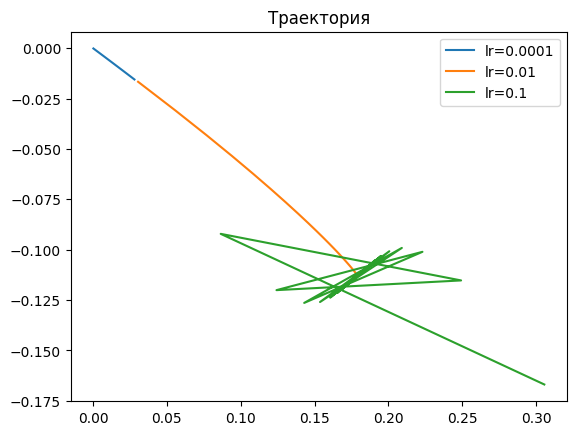

Name: Пономарев Артём Алексеевич, Group: ЗФИбд-01-24, StudentNumber: 1132243698, DateTime: 2026-04-27 13:18:51


In [98]:
def gradient_descent(X, y, lr):
    w = np.zeros(X.shape[1])
    trajectory = []

    for _ in range(100):
        grad = 2 * X.T @ (X @ w - y) / len(y)
        w -= lr * grad
        trajectory.append(w.copy())

    return np.array(trajectory)


for lr in [0.0001, 0.01, 0.1]:
    traj = gradient_descent(X, y, lr)
    plt.plot(traj[:, 0], traj[:, 1], label=f"lr={lr}")

plt.legend()
plt.title("Траектория")
plt.show()

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")

### Домашнее задание № 7

#### Реализуйте полный градиентный спуск с матричными операциями

Градиент в матричной форме $$\nabla Q(\theta) = -2X^Ty + 2X^TX\theta = 2X^T(X\theta - y).$$

Сравните скорость работы обычного градиентного спуска и матричной формы



In [99]:
n_features = 100
n_objects = 10000
num_steps = 2


np.random.seed(1)
w_true = np.random.normal(0, 0.1, size=(n_features, ))
w_0 = np.random.uniform(-2, 2, (n_features))

X = np.random.uniform(-5, 5, (n_objects, n_features))
y = np.dot(X, w_true) + np.random.normal(0, 1, (n_objects))

In [100]:
import time

start = time.time()

for _ in range(1000):
    grad = 2 * X.T @ (X @ w - y)

end = time.time()

print("Время работы матричного варианта:", end - start)

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 8 is different from 100)

### Домашнее задание № 8

Используйте датасет объявлений по продаже машин (), чтобы спрогнозировать стоимость машин. . Для дальнейшей работы сделайте следующее:

1. Проверить наличие пропущенных значений, дубликатов, выбросов и шума в данных.
    - Провести полный разведочный анализ данных (EDA), включающий:
        - Анализ структуры и типов данных.
        - Подсчёт количества пропущенных значений и дубликатов.
        - Определение выбросов с помощью описательной статистики и визуальных методов
        - Проверку распределения признаков
        - Анализ категориальных признаков

- Определить, какие числовые признаки наиболее сильно коррелируют с целевой переменной.
    - Построить матрицу корреляций
    - Визуализировать её с помощью тепловой карты (heatmap)

2. Разделите данные на обучающую и тестовую выборки

Сходимость стохастического градиентного спуска в зависимости от размера батча
```python
batch_sizes = np.arange(5, 500, 10)
```

3. Сделайте по несколько запусков  стохастического градиентного спуска на обучающей выборке для каждого размера батча из списка. Замерьте время и количество итераций до сходимости.

4. Постройте график зависимости количества шагов до сходимости от размера батча.
5. Постройте график зависимости времени до сходимости от размера батча.

6. Сравните для каждого метода результаты на тестовой выборке по метрикам MSE и $R^2$ с регуляризацией и без регуляризации. Постройте для каждого метода график со значениями функции потерь MSE с регуляризацией и без регуляризации.
4. Напишите выводы.

In [ ]:
### YOUR CODE:


print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")